# Tema E - Analiza dataset-ului Titanic in Google Colab

In acest notebook o sa fac o scurta analiza a datelor despre pasagerii de pe Titanic, sa vad cine a avut sanse mai mari de supravietuire. Ma voi folosi de Pandas si Seaborn ca sa investighez cum a contat sexul si clasa biletului in toata tragedia asta.

In [8]:
# Importam bibliotecile si incarcam datele
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setam o tema misto pentru grafice
sns.set_theme(style='whitegrid', palette='muted')

# Incarcam dataset-ul
titanic = sns.load_dataset('titanic')
print("Gata, am incarcat dataset-ul cu succes!")

Gata, am incarcat dataset-ul cu succes!


## Statistici descriptive si o prima privire peste date

Aici scot in evidenta dimensiunea setului de date, verific daca avem valori lipsa si calculez rata generala de supravietuire. Dupa aia, grupez datele ca sa vad exact cum arata rata de supravietuire in functie de sex si clasa.

In [9]:
# --- Cum arata datele la prima vedere ---
print("=== Informatii generale ===")
print(f"Dimensiune: {titanic.shape}")
print(f"\nValori lipsa:\n{titanic.isnull().sum()[titanic.isnull().sum() > 0]}")
print(f"\nRata globala de supravietuire: {titanic['survived'].mean():.1%}")

# --- Rata de supravietuire pe sexe ---
print("\n=== Rata de supravietuire per sex ===")
rata_sex = titanic.groupby('sex', observed=True)['survived'].mean().round(3)
print(rata_sex)

# --- Rata de supravietuire pe clase ---
print("\n=== Rata de supravietuire per clasa ===")
rata_clasa = titanic.groupby('class', observed=True)['survived'].mean().round(3)
print(rata_clasa)

# --- Un tabel mai fain: supravietuire per sex si clasa ---
print("\n=== Rata de supravietuire per sex si clasa ===")
pivot = titanic.pivot_table(values='survived', index='class', columns='sex', aggfunc='mean', observed=True).round(3)
print(pivot)

=== Informatii generale ===
Dimensiune: (891, 15)

Valori lipsa:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Rata globala de supravietuire: 38.4%

=== Rata de supravietuire per sex ===
sex
female    0.742
male      0.189
Name: survived, dtype: float64

=== Rata de supravietuire per clasa ===
class
First     0.630
Second    0.473
Third     0.242
Name: survived, dtype: float64

=== Rata de supravietuire per sex si clasa ===
sex     female   male
class                
First    0.968  0.369
Second   0.921  0.157
Third    0.500  0.135


## Vizualizarea datelor

Ca sa fie totul mai clar si mai usor de inteles din prima, o sa fac cateva grafice (mai exact o figura cu 3 subplot-uri) folosind seaborn. Graficele cu bare o sa ne arate super clar cum difera rata de supravietuire cand comparam barbatii cu femeile si clasele intre ele.

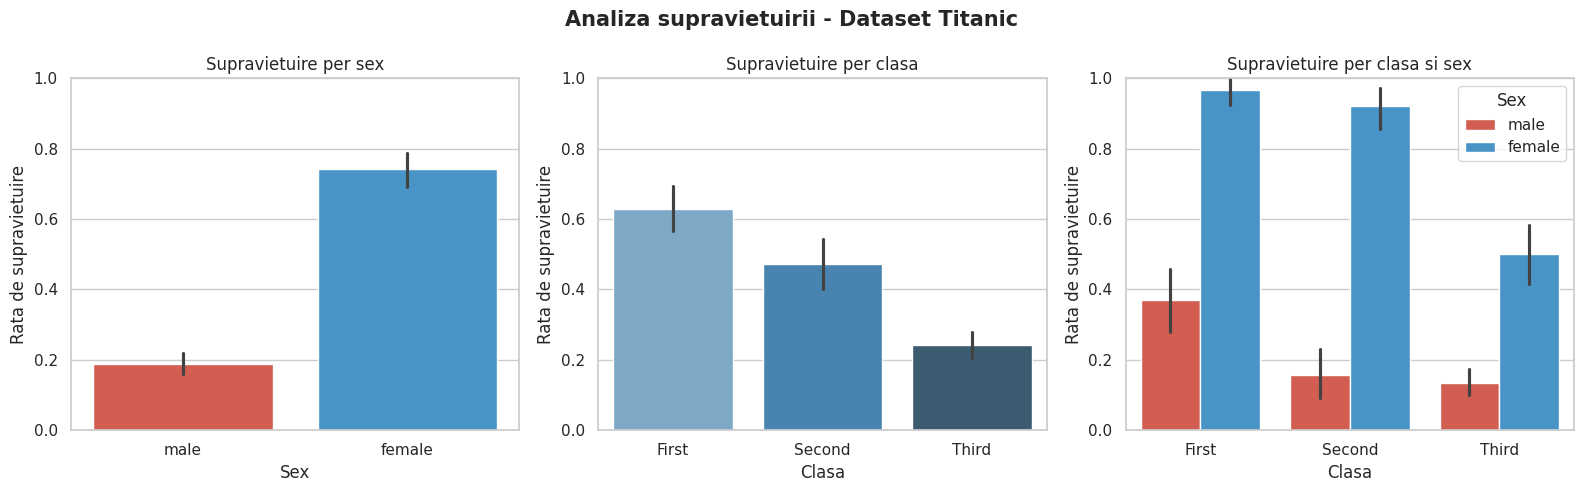

In [10]:
# --- Partea de vizualizare ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analiza supravietuirii - Dataset Titanic', fontsize=15, fontweight='bold')

# Primul grafic: Supravietuirea per sex
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', ax=axes[0], errorbar='ci', palette=['#e74c3c', '#3498db'], legend=False)
axes[0].set_title('Supravietuire per sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Rata de supravietuire')
axes[0].set_ylim(0, 1)

# Al doilea grafic: Supravietuirea per clasa
sns.barplot(data=titanic, x='class', y='survived', hue='class', ax=axes[1], errorbar='ci', order=['First', 'Second', 'Third'], palette='Blues_d', legend=False)
axes[1].set_title('Supravietuire per clasa')
axes[1].set_xlabel('Clasa')
axes[1].set_ylabel('Rata de supravietuire')
axes[1].set_ylim(0, 1)

# Al treilea grafic: Supravietuire per clasa si sex combinat
sns.barplot(data=titanic, x='class', y='survived', hue='sex', ax=axes[2], errorbar='ci', order=['First', 'Second', 'Third'], palette=['#e74c3c', '#3498db'])
axes[2].set_title('Supravietuire per clasa si sex')
axes[2].set_xlabel('Clasa')
axes[2].set_ylabel('Rata de supravietuire')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Sex')

plt.tight_layout()

## Concluzii

Analizand datele, e destul de clar ca sansele de a scapa de pe Titanic nu au fost deloc egale pentru toti. Femeile au supravietuit intr-un numar mult mai mare decat barbatii, ceea ce ne arata ca regula "femeile si copiii primii" chiar a fost luata in serios. Pe langa asta, daca aveai bilet la clasa I, probabilitatea sa te salvezi era mult mai mare fata de clasa a III-a. Practic, statutul social si banii au contat destul de mult in timpul evacuarii.